# 06 — Hyperparameter Tuning and Model Selection

Tune the prespecified XGBoost and Random Forest candidates on training-only chronological folds, then compare their complete pipelines with the stage-05b neural candidate. Neural inputs are stage-03 transformed snapshot features; tree inputs are stage-04 selected engineered features. This is a comparison of complete modeling pipelines, not an isolated architecture experiment. Rank candidates by validation PR-AUC, then F2; choose each threshold by validation F2. Test metrics are never used. Earlier exploratory test exposure prevents describing this as a fresh independent confirmation.

In [1]:
from pathlib import Path
from time import perf_counter
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.stats import randint, uniform, loguniform
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, classification_report, confusion_matrix, f1_score, fbeta_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
sns.set_theme(style="whitegrid")
project_root = Path.cwd()
if not (project_root / "data" / "processed").exists():
    project_root = project_root.parent
data_dir = project_root / "data" / "processed"
results_dir = project_root / "reports" / "model_results"
figures_dir = project_root / "reports" / "figures"
models_dir = project_root / "models"
for directory in [results_dir, figures_dir, models_dir]:
    directory.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42
import sys
sys.path.insert(0, str(project_root))
from src.modeling.artifacts import BalancedXGBClassifier, check_splits, write_manifest, verify_manifest


## 1. Load Training and Validation Data

In [2]:
train_df = pd.read_csv(data_dir / "04_train_engineered.csv", parse_dates=["timestamp"])
validation_df = pd.read_csv(data_dir / "04_validation_engineered.csv", parse_dates=["timestamp"])
selected_features = pd.read_csv(results_dir / "04_selected_features.csv")["feature"].tolist()
candidates = pd.read_csv(results_dir / "05_tuning_candidates.csv")["model"].tolist()
if candidates != ["XGBoost", "Random Forest"]:
    raise RuntimeError(f"Unexpected Step 05 candidates: {candidates}")
X_train = train_df[selected_features].copy()
y_train = train_df["failure"].astype("int8").copy()
X_validation = validation_df[selected_features].copy()
y_validation = validation_df["failure"].astype("int8").copy()
print(f"Training: {len(X_train):,} rows, {len(selected_features)} predictors, {y_train.sum():,} failures")
print(f"Validation: {len(X_validation):,} rows, {len(selected_features)} predictors, {y_validation.sum():,} failures")
print("Tuning candidates:", candidates)
print("Test data scored:", False)
_ = check_splits(project_root)


Training: 84,336 rows, 86 predictors, 1,877 failures
Validation: 21,072 rows, 86 predictors, 1,485 failures
Tuning candidates: ['XGBoost', 'Random Forest']
Test data scored: False


## 2. Expanding Chronological Tuning Folds

Three inner folds use complete timestamp blocks: 55%→15%, 70%→15%, and 85%→15%. Each fold trains only on observations earlier than its assessment window, and all turbines sharing a timestamp remain together. These folds use only the Step 03 training period.

In [3]:
ordered_timestamps = pd.Index(train_df["timestamp"].drop_duplicates().sort_values())
fold_bounds = [(0.55, 0.70), (0.70, 0.85), (0.85, 1.00)]
chronological_cv = []
fold_rows = []
for fold_number, (validation_start_fraction, validation_end_fraction) in enumerate(fold_bounds, start=1):
    start_position = int(np.floor(len(ordered_timestamps) * validation_start_fraction))
    end_position = int(np.floor(len(ordered_timestamps) * validation_end_fraction))
    validation_start = ordered_timestamps[start_position]
    train_indices = np.flatnonzero(train_df["timestamp"].lt(validation_start).to_numpy())
    if end_position < len(ordered_timestamps):
        validation_end = ordered_timestamps[end_position]
        validation_indices = np.flatnonzero(train_df["timestamp"].ge(validation_start).to_numpy() & train_df["timestamp"].lt(validation_end).to_numpy())
    else:
        validation_end = ordered_timestamps[-1]
        validation_indices = np.flatnonzero(train_df["timestamp"].ge(validation_start).to_numpy())
    chronological_cv.append((train_indices, validation_indices))
    fold_rows.append({"fold": fold_number, "training_rows": len(train_indices), "assessment_rows": len(validation_indices), "training_end": train_df.iloc[train_indices]["timestamp"].max(), "assessment_start": train_df.iloc[validation_indices]["timestamp"].min(), "assessment_end": train_df.iloc[validation_indices]["timestamp"].max(), "assessment_failures": int(y_train.iloc[validation_indices].sum())})
fold_report = pd.DataFrame(fold_rows).set_index("fold")
display(fold_report)
print("Every fold is strictly chronological:", all(train_df.iloc[tr]["timestamp"].max() < train_df.iloc[va]["timestamp"].min() for tr, va in chronological_cv))

,training_rows,assessment_rows,training_end,assessment_start,assessment_end,assessment_failures
fold,,,,,,
1,46452,12672,2024-01-27 21:00:00,2024-01-27 21:10:00,2024-02-04 05:00:00,281
2,59124,12672,2024-02-04 05:00:00,2024-02-04 05:10:00,2024-02-11 13:00:00,305
3,71796,12540,2024-02-11 13:00:00,2024-02-11 13:10:00,2024-02-18 21:00:00,911


Every fold is strictly chronological: True


## 3. Randomized Hyperparameter Search

Eight configurations per candidate are evaluated across the three chronological folds. Internal selection prioritizes mean failure recall at threshold 0.50 and uses mean PR-AUC as the tie-breaker. Preprocessing is refitted inside every fold.

In [4]:
categorical_features = ["rated_power_kW"]
numeric_features = [c for c in selected_features if c not in categorical_features]
preprocessor = ColumnTransformer([("numeric", SimpleImputer(strategy="median"), numeric_features), ("rated_power", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), categorical_features)], remainder="drop", verbose_feature_names_out=False)
scale_pos_weight = y_train.eq(0).sum() / y_train.eq(1).sum()
candidate_pipelines = {
    "XGBoost": Pipeline([("preprocessor", preprocessor), ("model", BalancedXGBClassifier(objective="binary:logistic", eval_metric="aucpr", random_state=RANDOM_STATE, n_jobs=-1))]),
    "Random Forest": Pipeline([("preprocessor", preprocessor), ("model", RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1))]),
}
parameter_distributions = {
    "XGBoost": {"model__n_estimators": randint(150, 501), "model__max_depth": randint(3, 9), "model__learning_rate": loguniform(0.02, 0.20), "model__min_child_weight": randint(1, 9), "model__subsample": uniform(0.70, 0.30), "model__colsample_bytree": uniform(0.70, 0.30), "model__reg_lambda": loguniform(0.1, 10.0)},
    "Random Forest": {"model__n_estimators": randint(200, 601), "model__max_depth": [8, 12, 16, 20, None], "model__min_samples_split": randint(2, 21), "model__min_samples_leaf": randint(1, 11), "model__max_features": ["sqrt", "log2", 0.5], "model__class_weight": ["balanced", "balanced_subsample"]},
}
scoring = {"recall": "recall", "pr_auc": "average_precision", "roc_auc": "roc_auc"}

In [5]:
search_tables = []
best_parameters = {}
for model_name in candidates:
    started = perf_counter()
    search = RandomizedSearchCV(candidate_pipelines[model_name], parameter_distributions[model_name], n_iter=8, scoring=scoring, refit=False, cv=chronological_cv, random_state=RANDOM_STATE, n_jobs=1, return_train_score=True, error_score="raise")
    search.fit(X_train, y_train)
    table = pd.DataFrame(search.cv_results_)
    table.insert(0, "model", model_name)
    table["recall_gap"] = table["mean_train_recall"] - table["mean_test_recall"]
    table["pr_auc_gap"] = table["mean_train_pr_auc"] - table["mean_test_pr_auc"]
    table = table.sort_values(["mean_test_recall", "mean_test_pr_auc", "recall_gap"], ascending=[False, False, True]).reset_index(drop=True)
    best_parameters[model_name] = table.iloc[0]["params"]
    search_tables.append(table)
    print(f"{model_name}: completed 24 chronological fits in {perf_counter() - started:,.1f} seconds")
    display(table.head(3)[["model", "mean_test_recall", "mean_test_pr_auc", "mean_test_roc_auc", "recall_gap", "pr_auc_gap", "params"]])
tuning_results = pd.concat(search_tables, ignore_index=True)

XGBoost: completed 24 chronological fits in 35.7 seconds


,model,mean_test_recall,mean_test_pr_auc,mean_test_roc_auc,recall_gap,pr_auc_gap,params
0,XGBoost,0.2575,0.6154,0.9606,0.7425,0.3845,{'model__colsample_bytree': 0.9579821220208962...
1,XGBoost,0.2521,0.5644,0.9089,0.7479,0.4356,{'model__colsample_bytree': 0.9165996316800473...
2,XGBoost,0.2382,0.5773,0.9290,0.7618,0.4227,{'model__colsample_bytree': 0.8123620356542087...


Random Forest: completed 24 chronological fits in 155.0 seconds


,model,mean_test_recall,mean_test_pr_auc,mean_test_roc_auc,recall_gap,pr_auc_gap,params
0,Random Forest,0.1646,0.7022,0.9813,0.8354,0.2946,"{'model__class_weight': 'balanced', 'model__ma..."
1,Random Forest,0.1581,0.6956,0.9757,0.8419,0.3014,"{'model__class_weight': 'balanced', 'model__ma..."
2,Random Forest,0.1164,0.7622,0.9832,0.8836,0.2325,"{'model__class_weight': 'balanced_subsample', ..."


## 4. Validation Performance and Threshold Selection

Each tree configuration is fitted on training data. All candidates use the same validation rows, aligned by source index. Thresholds maximize validation F2, which places greater emphasis on recall; PR-AUC selects the overall pipeline. The original held-out test scores are not read here.

In [6]:
def metrics_at_threshold(y_true, probabilities, threshold):
    predictions = (probabilities >= threshold).astype("int8")
    return {"threshold": threshold, "recall": recall_score(y_true, predictions), "precision": precision_score(y_true, predictions, zero_division=0), "f1": f1_score(y_true, predictions), "f2": fbeta_score(y_true, predictions, beta=2, zero_division=0), "predicted_positive_pct": predictions.mean() * 100}

tuned_models = {}
validation_probabilities = {}
threshold_tables = []
comparison_rows = []
threshold_grid = np.round(np.linspace(0.01, 0.99, 197), 3)
for model_name in candidates:
    tuned = clone(candidate_pipelines[model_name]).set_params(**best_parameters[model_name])
    tuned.fit(X_train, y_train)
    probabilities = tuned.predict_proba(X_validation)[:, 1]
    threshold_table = pd.DataFrame([metrics_at_threshold(y_validation, probabilities, threshold) for threshold in threshold_grid])
    threshold_table.insert(0, "model", model_name)
    threshold_table = threshold_table.sort_values(["f2", "precision", "threshold"], ascending=False).reset_index(drop=True)
    selected = threshold_table.iloc[0]
    comparison_rows.append({"model": model_name, **selected[["threshold", "recall", "precision", "f1", "f2", "predicted_positive_pct"]].to_dict(), "pr_auc": average_precision_score(y_validation, probabilities), "roc_auc": roc_auc_score(y_validation, probabilities)})
    threshold_tables.append(threshold_table)
    tuned_models[model_name] = tuned
    validation_probabilities[model_name] = probabilities

nn_dir = models_dir / "neural_network_comparison"
# The neural manifest includes a raw-source hash; use its producer's validator.
from src.modeling.neural_networks import load_data
load_data(project_root)
current_manifest = json.loads((data_dir / "03_ann_manifest.json").read_text())
if json.loads((nn_dir / "data_manifest.json").read_text()) != current_manifest:
    raise RuntimeError("Neural models use obsolete preprocessing; rerun 05b.")
nn_selection = json.loads((nn_dir / "selection.json").read_text())
nn_name = "Neural Network: " + nn_selection["model"]
nn_metadata = pd.read_csv(data_dir / "03_validation_metadata.csv")
nn_prob = pd.Series(np.load(nn_dir / f"{nn_selection['model']}_validation_probability.npy"), index=nn_metadata["source_index"])
probabilities = nn_prob.loc[validation_df["source_index"]].to_numpy()
threshold_table = pd.DataFrame([metrics_at_threshold(y_validation, probabilities, threshold) for threshold in threshold_grid])
threshold_table.insert(0, "model", nn_name)
threshold_table = threshold_table.sort_values(["f2", "precision", "threshold"], ascending=False).reset_index(drop=True)
selected = threshold_table.iloc[0]
comparison_rows.append({"model": nn_name, **selected[["threshold", "recall", "precision", "f1", "f2", "predicted_positive_pct"]].to_dict(), "pr_auc": average_precision_score(y_validation, probabilities), "roc_auc": roc_auc_score(y_validation, probabilities)})
threshold_tables.append(threshold_table)
validation_probabilities[nn_name] = probabilities
tuned_comparison = pd.DataFrame(comparison_rows).sort_values(["pr_auc", "f2", "recall"], ascending=False).reset_index(drop=True)
display(tuned_comparison)

,model,threshold,recall,precision,f1,f2,predicted_positive_pct,pr_auc,roc_auc
0,XGBoost,0.0150,0.8815,0.5969,0.7118,0.8047,10.4072,0.8336,0.9797
1,Random Forest,0.2550,0.8734,0.6242,0.7280,0.8088,9.8614,0.7995,0.9812
2,Neural Network: 128_64_adam,0.2900,0.8566,0.4097,0.5542,0.7032,14.7352,0.5646,0.9530


## 5. Validation Diagnostics and Final Selection

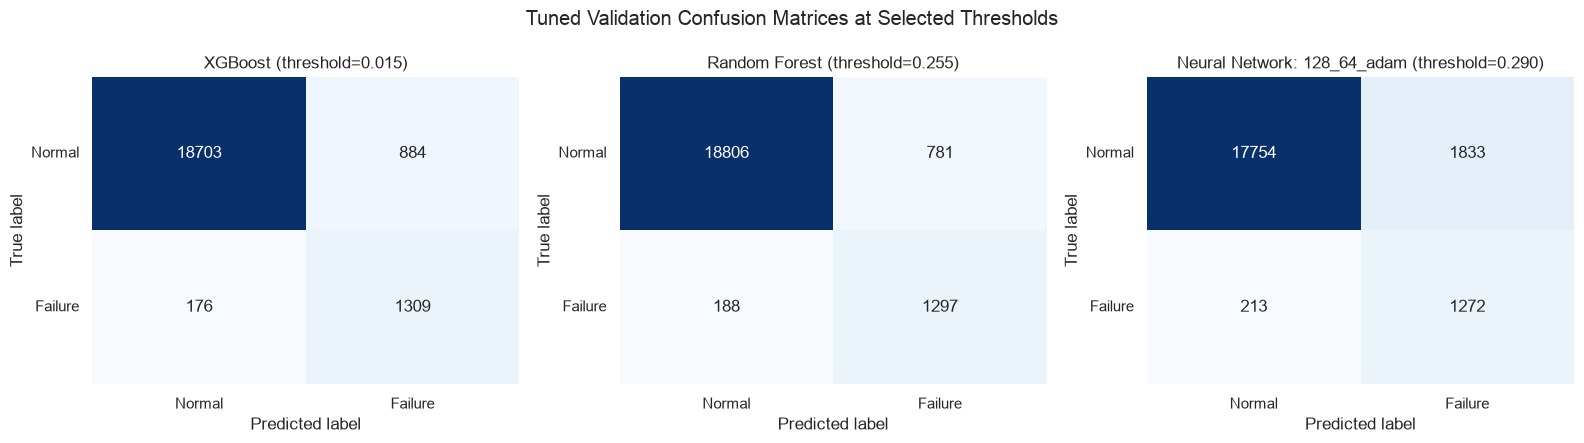

,model,class,precision,recall,f1-score,support
1,XGBoost,failure,0.5969,0.8815,0.7118,"1,485.0000"
3,Random Forest,failure,0.6242,0.8734,0.7280,"1,485.0000"
5,Neural Network: 128_64_adam,failure,0.4097,0.8566,0.5542,"1,485.0000"


In [7]:
fig, axes = plt.subplots(1, len(tuned_comparison), figsize=(16, 4.5))
classification_rows = []
for axis, row in zip(axes, tuned_comparison.to_dict("records")):
    model_name = row["model"]
    predictions = (validation_probabilities[model_name] >= row["threshold"]).astype("int8")
    matrix = confusion_matrix(y_validation, predictions)
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axis)
    axis.set(title=f"{model_name} (threshold={row['threshold']:.3f})", xlabel="Predicted label", ylabel="True label")
    axis.set_xticklabels(["Normal", "Failure"]); axis.set_yticklabels(["Normal", "Failure"], rotation=0)
    report = classification_report(y_validation, predictions, target_names=["normal", "failure"], output_dict=True, zero_division=0)
    for class_name in ["normal", "failure"]:
        classification_rows.append({"model": model_name, "class": class_name, **{key: report[class_name][key] for key in ["precision", "recall", "f1-score", "support"]}})
fig.suptitle("Tuned Validation Confusion Matrices at Selected Thresholds")
fig.tight_layout()
figure_path = figures_dir / "06_tuned_validation_confusion_matrices.png"
fig.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()
classification_reports = pd.DataFrame(classification_rows)
display(classification_reports.loc[classification_reports["class"] == "failure"].sort_values("recall", ascending=False))

In [8]:
selected_model_name = tuned_comparison.iloc[0]["model"]
selected_threshold = float(tuned_comparison.iloc[0]["threshold"])
for model_name, model in tuned_models.items():
    joblib.dump(model, models_dir / f"06_{model_name.lower().replace(' ', '_')}_tuned.joblib")
if selected_model_name == nn_name:
    model_path = nn_dir / f"{nn_selection['model']}.keras"
    representation = "ann"
else:
    model_path = models_dir / f"06_{selected_model_name.lower().replace(' ', '_')}_tuned.joblib"
    representation = "engineered"
selection = {"model": selected_model_name, "threshold": selected_threshold,
    "model_path": str(model_path.relative_to(project_root)), "representation": representation,
    "selection_rule": "validation PR-AUC, then F2 and recall; threshold maximizes validation F2",
    "refit_policy": "Evaluate the frozen training-fitted checkpoint without refitting to preserve threshold calibration."}
(models_dir / "06_selected_threshold.json").write_text(json.dumps(selection, indent=2))
tuning_export = tuning_results.copy()
tuning_export["params"] = tuning_export["params"].astype(str)
tuning_export.to_csv(results_dir / "06_tuning_results.csv", index=False)
pd.concat(threshold_tables, ignore_index=True).to_csv(results_dir / "06_threshold_results.csv", index=False)
tuned_comparison.to_csv(results_dir / "06_tuned_validation_metrics.csv", index=False)
classification_reports.to_csv(results_dir / "06_tuned_classification_reports.csv", index=False)
paths = [model_path, models_dir / "06_selected_threshold.json", results_dir / "06_tuned_validation_metrics.csv",
    results_dir / "04_selected_features.csv", data_dir / "03_ann_manifest.json", nn_dir / "preprocessor.joblib"]
paths += [data_dir / f"04_{s}_engineered.csv" for s in ["train", "validation", "test"]]
paths += [results_dir / "05_baseline_metrics.csv", results_dir / "04_feature_ablation.csv", nn_dir / "comparison.csv", nn_dir / "histories.json", nn_dir / "selection.json", nn_dir / "learning_curves.png"]
write_manifest(project_root, paths, models_dir / "06_selection_manifest.json")
print("Frozen selection:", selection)
print("Test scores used for selection:", False)


Frozen selection: {'model': 'XGBoost', 'threshold': 0.015, 'model_path': 'models/06_xgboost_tuned.joblib', 'representation': 'engineered', 'selection_rule': 'validation PR-AUC, then F2 and recall; threshold maximizes validation F2', 'refit_policy': 'Evaluate the frozen training-fitted checkpoint without refitting to preserve threshold calibration.'}
Test scores used for selection: False


## Key Findings Recap

- Each tree family evaluated eight configurations over three training-only chronological folds.
- XGBoost imbalance weighting was recomputed within each training fold.
- Two tuned tree pipelines and the validation-selected neural checkpoint were compared on the same validation rows.
- XGBoost led the documented PR-AUC-first selection with PR-AUC 0.8336 and F2 0.8047.
- Its frozen threshold is 0.015, with validation recall 0.8815 and precision 0.5969.
- The selected checkpoint and artifact fingerprints were saved; test outcomes did not influence selection.